# 🛡️ Zero-Day Intrusion Detection System — Autoencoder-Based Anomaly Detection
## CSE-CIC-IDS2018 Dataset | AWS t3.large Optimized | With Full Caching

**Project Goal:** Train an autoencoder exclusively on **benign network traffic** to learn what "normal" looks like, then flag deviations (anomalies) as potential intrusions — including **unseen zero-day attacks**.

**Pipeline Overview:**
1. Load & merge all 10 CSVs → cached as `cleaned_data.parquet`
2. Clean & preprocess features → cached in parquet
3. Split + Scale → cached as `.npy` arrays
4. Train Autoencoder → cached as `.keras` model
5. Compute reconstruction errors → cached as `.npy`
6. Evaluate & visualize (always re-runs — fast, plots shown inline)

**⚡ Cache behaviour:** Each expensive step checks for its cache file first.
If found → loads instantly and skips recomputation. If missing → runs and saves.
Delete individual cache files to re-run only specific stages.
Set `FORCE_RERUN = True` in Cell 2 to re-run everything from scratch.

---
**Environment:** Ubuntu 24.04 | EC2 t3.large | 8GB RAM + 16GB swap | Python 3.10+

## Cell 1 — Install / Verify Dependencies

In [1]:
# ── Install dependencies (run once; safe to re-run) ──────────────────────────
# Uncomment the line below if packages are missing in your venv:
# !pip install numpy pandas scikit-learn tensorflow matplotlib seaborn tqdm pyarrow joblib --quiet

import sys, platform, os
import numpy as np
import pandas as pd
import tensorflow as tf
import sklearn, matplotlib, seaborn

print(f"Python     : {sys.version.split()[0]}")
print(f"Platform   : {platform.node()}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
print(f"TensorFlow : {tf.__version__}")
print(f"Scikit     : {sklearn.__version__}")
print(f"Matplotlib : {matplotlib.__version__}")
print(f"Seaborn    : {seaborn.__version__}")

mem_bytes = os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES')
print(f"\nSystem RAM : {mem_bytes / (1024**3):.1f} GB")

I0000 00:00:1776699593.821188    1474 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776699595.362369    1474 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776699600.552588    1474 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Python     : 3.12.3
Platform   : ip-172-31-94-241
NumPy      : 2.4.4
Pandas     : 3.0.2
TensorFlow : 2.21.0
Scikit     : 1.8.0
Matplotlib : 3.10.8
Seaborn    : 0.13.2

System RAM : 7.6 GB


## Cell 2 — Configuration & Cache Paths

All tuneable settings and cache file paths live here.
This is the **only cell you ever need to edit**.

In [2]:
import os

# ╔══════════════════════════════════════════════════════════════════╗
# ║                     PROJECT PATHS                               ║
# ╚══════════════════════════════════════════════════════════════════╝
DATA_PATH  = os.path.expanduser("~/ids2018/data")     # raw CSVs
OUTPUT_DIR = os.path.expanduser("~/ids2018/outputs")  # plots, model, results
CACHE_DIR  = os.path.expanduser("~/ids2018/cache")    # intermediate cache files

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR,  exist_ok=True)

# ╔══════════════════════════════════════════════════════════════════╗
# ║                     CACHE FILE PATHS                            ║
# ║  Delete any individual file below to re-run just that stage.    ║
# ╚══════════════════════════════════════════════════════════════════╝
CACHE_PARQUET      = os.path.join(CACHE_DIR, "cleaned_data.parquet")  # Stage 1+2
CACHE_X_TRAIN      = os.path.join(CACHE_DIR, "X_train_scaled.npy")    # Stage 3
CACHE_X_VAL        = os.path.join(CACHE_DIR, "X_val_scaled.npy")      # Stage 3
CACHE_X_ALL        = os.path.join(CACHE_DIR, "X_all_scaled.npy")      # Stage 3
CACHE_Y_ALL        = os.path.join(CACHE_DIR, "y_all.npy")             # Stage 3
CACHE_LABELS_ALL   = os.path.join(CACHE_DIR, "labels_all.npy")        # Stage 3
CACHE_SCALER       = os.path.join(CACHE_DIR, "robust_scaler.joblib")  # Stage 3
CACHE_MODEL        = os.path.join(OUTPUT_DIR, "autoencoder_best.keras")# Stage 4
CACHE_HISTORY      = os.path.join(CACHE_DIR, "train_history.npy")     # Stage 4
CACHE_RECON_ERRORS = os.path.join(CACHE_DIR, "recon_errors.npy")      # Stage 5
CACHE_VAL_ERRORS   = os.path.join(CACHE_DIR, "val_errors.npy")        # Stage 5

# ╔══════════════════════════════════════════════════════════════════╗
# ║  FORCE_RERUN: set True to ignore ALL caches and redo everything ║
# ╚══════════════════════════════════════════════════════════════════╝
FORCE_RERUN = False

# ── Memory-safe loading ──────────────────────────────────────────────────────
CHUNK_SIZE        = 100000   # rows per CSV chunk (lower this if you get OOM)
MAX_ROWS_PER_FILE = 500000   # cap per CSV file; set to None to load everything

# ── Label settings ───────────────────────────────────────────────────────────
LABEL_COL  = "Label"    # column name in the CSVs
BENIGN_STR = "benign"   # lowercase string that identifies normal traffic

# ── Columns to drop before modelling (identifiers, not traffic features) ─────
DROP_COLS = ["Timestamp", "Src IP", "Dst IP", "Src Port", "Dst Port", "Protocol"]

# ── Autoencoder hyperparameters ──────────────────────────────────────────────
ENCODING_DIM         = 32        # bottleneck size
HIDDEN_DIMS          = [128, 64] # encoder layer sizes (decoder mirrors these)
DROPOUT_RATE         = 0.2
BATCH_SIZE           = 512
EPOCHS               = 50
LEARNING_RATE        = 1e-3
THRESHOLD_PERCENTILE = 99        # P99 = ~1% FPR on benign val set

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42

print(f"Data path  : {DATA_PATH}")
print(f"Cache dir  : {CACHE_DIR}")
print(f"Output dir : {OUTPUT_DIR}")
print(f"FORCE_RERUN: {FORCE_RERUN}")

Data path  : /home/ubuntu/ids2018/data
Cache dir  : /home/ubuntu/ids2018/cache
Output dir : /home/ubuntu/ids2018/outputs
FORCE_RERUN: False


## Cell 3 — Imports

In [3]:
import warnings, gc, time, shutil
from pathlib import Path
from IPython.display import Image, display  # ← for inline plot display

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
from tqdm import tqdm

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks

import matplotlib
# ── IMPORTANT: Use Agg backend so plots save reliably on headless AWS.
# We then use IPython display() to render the saved PNG inline in the notebook.
# This gives you BOTH: the image visible in the notebook output AND saved to disk.
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)
FIGSIZE = (10, 5)

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("All imports successful ✓")
print("Plots will be saved to disk AND displayed inline in this notebook.")

All imports successful ✓
Plots will be saved to disk AND displayed inline in this notebook.


## Cell 4 — Plot Helper: Save + Show Inline

Every plot cell calls `save_and_show(fig, filename)` which:
1. Saves the PNG to `~/ids2018/outputs/` at 150 DPI
2. Closes the matplotlib figure (frees RAM)
3. Renders the saved PNG **inline in the notebook output** via IPython display

This means the image is visible when you view or download the `.ipynb` file.

In [4]:
def save_and_show(fig, filename: str):
    """
    Save a matplotlib figure to OUTPUT_DIR and display it inline.

    Parameters
    ----------
    fig      : matplotlib Figure object
    filename : filename without path, e.g. 'plot_roc_curve.png'

    Behaviour
    ---------
    - Saves at 150 DPI to ~/ids2018/outputs/<filename>
    - Closes figure to free RAM (important on t3.large)
    - Calls IPython display() so image appears in notebook cell output
      and is embedded in the .ipynb file for GitHub viewing
    """
    save_path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)  # free RAM
    display(Image(filename=save_path))  # show inline
    print(f"Saved: {save_path}")


print("save_and_show() helper ready ✓")

save_and_show() helper ready ✓


## Cell 5 — Cache Helper Utilities

In [5]:
def cache_exists(*paths) -> bool:
    """
    Returns True only if ALL given paths exist on disk AND FORCE_RERUN is False.
    A single missing file or FORCE_RERUN=True returns False → trigger re-run.
    """
    if FORCE_RERUN:
        return False
    return all(os.path.exists(p) for p in paths)


def cache_status(stage: str, *paths):
    """Print a clear HIT / MISS status message for a pipeline stage."""
    if cache_exists(*paths):
        sizes = [f"{os.path.getsize(p)/(1024**2):.1f} MB" for p in paths]
        print(f"  CACHE HIT  [{stage}]  ({', '.join(sizes)})")
    else:
        missing = [os.path.basename(p) for p in paths if not os.path.exists(p)]
        print(f"  CACHE MISS [{stage}]  missing: {missing}")


print("Current cache status:")
print("-" * 65)
cache_status("Stage 1+2 : Cleaned Parquet ",  CACHE_PARQUET)
cache_status("Stage 3   : Scaled Arrays   ",  CACHE_X_TRAIN, CACHE_X_VAL,
                                               CACHE_X_ALL, CACHE_Y_ALL,
                                               CACHE_LABELS_ALL, CACHE_SCALER)
cache_status("Stage 4   : Trained Model   ",  CACHE_MODEL, CACHE_HISTORY)
cache_status("Stage 5   : Recon Errors    ",  CACHE_RECON_ERRORS, CACHE_VAL_ERRORS)
print("-" * 65)
print("\nTip: delete a single cache file to re-run just that stage.")
print("Tip: set FORCE_RERUN = True in Cell 2 to re-run everything.")

Current cache status:
-----------------------------------------------------------------
  CACHE HIT  [Stage 1+2 : Cleaned Parquet ]  (322.4 MB)
  CACHE HIT  [Stage 3   : Scaled Arrays   ]  (425.6 MB, 106.4 MB, 834.0 MB, 24.5 MB, 39.6 MB, 0.0 MB)
  CACHE HIT  [Stage 4   : Trained Model   ]  (0.5 MB, 0.0 MB)
  CACHE HIT  [Stage 5   : Recon Errors    ]  (12.3 MB, 1.6 MB)
-----------------------------------------------------------------

Tip: delete a single cache file to re-run just that stage.
Tip: set FORCE_RERUN = True in Cell 2 to re-run everything.


## Cell 6 — Dataset Discovery

In [6]:
data_dir  = Path(DATA_PATH)
csv_files = sorted(data_dir.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(
        f"No CSV files found in {DATA_PATH}. Check DATA_PATH in Cell 2."
    )

print(f"Found {len(csv_files)} CSV files:\n")
for f in csv_files:
    size_mb = f.stat().st_size / (1024**2)
    print(f"  {f.name:<55}  {size_mb:>7.1f} MB")

Found 10 CSV files:

  Friday-02-03-2018_TrafficForML_CICFlowMeter.csv            336.0 MB
  Friday-16-02-2018_TrafficForML_CICFlowMeter.csv            318.3 MB
  Friday-23-02-2018_TrafficForML_CICFlowMeter.csv            365.1 MB
  Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv         3867.1 MB
  Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv          102.8 MB
  Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv          358.5 MB
  Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv          364.9 MB
  Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv         341.6 MB
  Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv         313.7 MB
  Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv         199.6 MB


## Cell 7 — Column Inspection (peek at first file)

In [7]:
# Read only 5 rows — instant, zero RAM cost
sample = pd.read_csv(csv_files[0], nrows=5, low_memory=False)
sample.columns = sample.columns.str.strip()

print(f"Columns : {sample.shape[1]}")
print(f"Dtypes  :\n{sample.dtypes.value_counts()}\n")
for i, col in enumerate(sample.columns):
    print(f"  [{i:>3}] {col}")

Columns : 80
Dtypes  :
int64      58
float64    20
str         2
Name: count, dtype: int64

  [  0] Dst Port
  [  1] Protocol
  [  2] Timestamp
  [  3] Flow Duration
  [  4] Tot Fwd Pkts
  [  5] Tot Bwd Pkts
  [  6] TotLen Fwd Pkts
  [  7] TotLen Bwd Pkts
  [  8] Fwd Pkt Len Max
  [  9] Fwd Pkt Len Min
  [ 10] Fwd Pkt Len Mean
  [ 11] Fwd Pkt Len Std
  [ 12] Bwd Pkt Len Max
  [ 13] Bwd Pkt Len Min
  [ 14] Bwd Pkt Len Mean
  [ 15] Bwd Pkt Len Std
  [ 16] Flow Byts/s
  [ 17] Flow Pkts/s
  [ 18] Flow IAT Mean
  [ 19] Flow IAT Std
  [ 20] Flow IAT Max
  [ 21] Flow IAT Min
  [ 22] Fwd IAT Tot
  [ 23] Fwd IAT Mean
  [ 24] Fwd IAT Std
  [ 25] Fwd IAT Max
  [ 26] Fwd IAT Min
  [ 27] Bwd IAT Tot
  [ 28] Bwd IAT Mean
  [ 29] Bwd IAT Std
  [ 30] Bwd IAT Max
  [ 31] Bwd IAT Min
  [ 32] Fwd PSH Flags
  [ 33] Bwd PSH Flags
  [ 34] Fwd URG Flags
  [ 35] Bwd URG Flags
  [ 36] Fwd Header Len
  [ 37] Bwd Header Len
  [ 38] Fwd Pkts/s
  [ 39] Bwd Pkts/s
  [ 40] Pkt Len Min
  [ 41] Pkt Len Max
  [ 42] Pkt

## Cell 8 — Stage 1+2: Load & Clean  *(cached → `cleaned_data.parquet`)*

**First run:** reads each CSV **chunk-by-chunk**, cleans each chunk immediately,
saves it as a temp parquet, then combines everything into one final parquet.
This avoids ever holding the entire raw dataset in RAM simultaneously.

**Subsequent runs:** skips everything and loads the parquet in seconds.

In [8]:
# ════════════════════════════════════════════════════════════════════
#  CACHE CHECK — Stage 1+2
# ════════════════════════════════════════════════════════════════════
if cache_exists(CACHE_PARQUET):
    print(f"CACHE HIT — loading cleaned data: {CACHE_PARQUET}")
    t0 = time.time()
    df = pd.read_parquet(CACHE_PARQUET)
    print(f"  Loaded {len(df):,} rows x {df.shape[1]} cols in {time.time()-t0:.1f}s")

else:
    # ════════════════════════════════════════════════════════════════
    # MEMORY-SAFE VERSION: process one chunk at a time
    #
    # WHY: Loading all CSVs → concat → clean all at once kills the
    # kernel on t3.large (8GB RAM). Instead:
    #   chunk → clean → save temp parquet → del → next chunk
    # Peak RAM usage = one chunk at a time, never the full dataset.
    # ════════════════════════════════════════════════════════════════
    print("CACHE MISS — loading and cleaning all CSV files safely...")

    TEMP_DIR = os.path.join(CACHE_DIR, "temp_clean_chunks")
    os.makedirs(TEMP_DIR, exist_ok=True)
    temp_files = []

    def clean_chunk(chunk):
        """
        Cleans a single DataFrame chunk in-place:
          - Strips column whitespace
          - Detects label column
          - Drops identifier columns (IP, port, timestamp)
          - Converts all features to numeric (coerce bad values to NaN)
          - Replaces inf with NaN
          - Drops all-NaN columns
          - Fills remaining NaN with column median
          - Downcasts float64 → float32 (saves ~50% RAM per chunk)
          - Re-attaches the label column
        """
        global LABEL_COL
        chunk.columns = chunk.columns.str.strip()

        if LABEL_COL not in chunk.columns:
            col_map = {c.lower(): c for c in chunk.columns}
            LABEL_COL = col_map.get("label", LABEL_COL)

        chunk[LABEL_COL] = chunk[LABEL_COL].astype(str).str.strip()

        existing_drop = [c for c in DROP_COLS if c in chunk.columns]
        chunk.drop(columns=existing_drop, inplace=True, errors="ignore")

        labels = chunk[LABEL_COL].copy()
        chunk.drop(columns=[LABEL_COL], inplace=True)

        for col in chunk.columns:
            chunk[col] = pd.to_numeric(chunk[col], errors="coerce")

        chunk.replace([np.inf, -np.inf], np.nan, inplace=True)

        all_nan = chunk.columns[chunk.isna().all()].tolist()
        chunk.drop(columns=all_nan, inplace=True)

        medians = chunk.median(numeric_only=True)
        chunk.fillna(medians, inplace=True)

        # Downcast to float32: halves memory per chunk
        for col in chunk.select_dtypes(include=["float64"]).columns:
            chunk[col] = chunk[col].astype("float32")

        chunk[LABEL_COL] = labels.values
        return chunk

    # ── STAGE 1: Read each CSV chunk-by-chunk ─────────────────────────────────
    t0 = time.time()
    temp_idx = 0

    for csv_path in tqdm(csv_files, desc="Processing CSV files"):
        reader = pd.read_csv(
            csv_path,
            chunksize=CHUNK_SIZE,
            low_memory=False,
            on_bad_lines="skip",
            encoding="utf-8",
            encoding_errors="replace"
        )
        rows_loaded = 0

        for chunk in reader:
            if MAX_ROWS_PER_FILE and rows_loaded >= MAX_ROWS_PER_FILE:
                break
            chunk = clean_chunk(chunk)
            temp_path = os.path.join(TEMP_DIR, f"chunk_{temp_idx}.parquet")
            chunk.to_parquet(temp_path, index=False, compression="snappy")
            temp_files.append(temp_path)
            rows_loaded += len(chunk)
            temp_idx += 1
            del chunk
            gc.collect()

    print(f"\n  Processed {len(temp_files)} cleaned chunks in {time.time()-t0:.1f}s")

    # ── STAGE 2: Combine temp chunks into final dataframe ─────────────────────
    print("\nCombining cleaned chunks...")
    frames = [pd.read_parquet(f) for f in tqdm(temp_files, desc="Loading temp chunks")]
    df = pd.concat(frames, ignore_index=True)
    del frames; gc.collect()

    n_before = len(df)
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"  Removed {n_before-len(df):,} duplicate rows")

    feat_cols = [c for c in df.columns if c != LABEL_COL]
    std_vals  = df[feat_cols].std(numeric_only=True)
    const_cols = std_vals[std_vals == 0].index.tolist()
    df.drop(columns=const_cols, inplace=True)
    print(f"  Dropped {len(const_cols)} constant-variance columns")
    print(f"\n  Final clean shape: {df.shape[0]:,} rows x {df.shape[1]} cols")

    # ── SAVE CACHE ────────────────────────────────────────────────────────────
    print(f"\nSaving cleaned cache: {CACHE_PARQUET}")
    df.to_parquet(CACHE_PARQUET, index=False, compression="snappy")
    size_mb = os.path.getsize(CACHE_PARQUET) / (1024**2)
    print(f"  Saved {size_mb:.1f} MB")

    shutil.rmtree(TEMP_DIR, ignore_errors=True)  # clean up temp chunks

print(f"\ndf shape: {df.shape[0]:,} rows x {df.shape[1]} cols")

CACHE HIT — loading cleaned data: /home/ubuntu/ids2018/cache/cleaned_data.parquet
  Loaded 3,215,110 rows x 69 cols in 3.7s

df shape: 3,215,110 rows x 69 cols


## Cell 9 — Label Distribution

In [9]:
# Guard: detect label column after potential cache load
if LABEL_COL not in df.columns:
    col_map = {c.lower(): c for c in df.columns}
    LABEL_COL = col_map.get("label", LABEL_COL)

label_counts = df[LABEL_COL].value_counts()
total = len(df)

print(f"{'Label':<42} {'Count':>10} {'%':>7}")
print("-" * 63)
for label, count in label_counts.items():
    print(f"  {label:<40} {count:>10,}  {100*count/total:>6.2f}%")
print("-" * 63)
print(f"  {'TOTAL':<40} {total:>10,}  100.00%")

Label                                           Count       %
---------------------------------------------------------------
  Benign                                    2,050,783   63.79%
  DDoS attacks-LOIC-HTTP                      498,301   15.50%
  DDOS attack-HOIC                            195,280    6.07%
  Bot                                         144,535    4.50%
  SSH-Bruteforce                               94,048    2.93%
  Infilteration                                90,390    2.81%
  DoS attacks-Hulk                             87,747    2.73%
  DoS attacks-GoldenEye                        41,406    1.29%
  DoS attacks-Slowloris                         9,908    0.31%
  DDOS attack-LOIC-UDP                          1,730    0.05%
  Brute Force -Web                                553    0.02%
  Brute Force -XSS                                228    0.01%
  SQL Injection                                    84    0.00%
  DoS attacks-SlowHTTPTest                         55  

## Cell 10 — Build Binary Label

In [10]:
# Binary label: 0 = benign, 1 = any attack
# Case-insensitive so 'Benign' and 'BENIGN' both match.
benign_mask       = df[LABEL_COL].str.lower().str.strip() == BENIGN_STR
df["is_attack"]   = (~benign_mask).astype(int)
df["attack_type"] = df[LABEL_COL]

n_benign = (df["is_attack"] == 0).sum()
n_attack = (df["is_attack"] == 1).sum()
print(f"Benign : {n_benign:>10,}  ({100*n_benign/total:.1f}%)")
print(f"Attack : {n_attack:>10,}  ({100*n_attack/total:.1f}%)")

FEATURE_COLS = [c for c in df.columns if c not in [LABEL_COL, "is_attack", "attack_type"]]
print(f"\nFeature dimensions: {len(FEATURE_COLS)}")

Benign :  2,050,783  (63.8%)
Attack :  1,164,327  (36.2%)

Feature dimensions: 68


## Cell 11 — Stage 3: Split & Scale  *(cached → `.npy` arrays + `.joblib` scaler)*

**First run:** creates splits, fits `RobustScaler` on benign-only training data,
scales all sets, clips extremes, saves everything.

**Subsequent runs:** loads pre-scaled arrays and fitted scaler instantly.

In [11]:
STAGE3_FILES = [CACHE_X_TRAIN, CACHE_X_VAL, CACHE_X_ALL,
                CACHE_Y_ALL, CACHE_LABELS_ALL, CACHE_SCALER]

# ════════════════════════════════════════════════════════════════════
#  CACHE CHECK — Stage 3
# ════════════════════════════════════════════════════════════════════
if cache_exists(*STAGE3_FILES):
    print("CACHE HIT — loading scaled arrays...")
    t0 = time.time()
    X_train_scaled = np.load(CACHE_X_TRAIN)
    X_val_scaled   = np.load(CACHE_X_VAL)
    X_all_scaled   = np.load(CACHE_X_ALL)
    y_all          = np.load(CACHE_Y_ALL)
    labels_all     = np.load(CACHE_LABELS_ALL, allow_pickle=True)
    scaler         = joblib.load(CACHE_SCALER)
    INPUT_DIM      = X_train_scaled.shape[1]
    print(f"  Loaded in {time.time()-t0:.1f}s")
    print(f"  X_train : {X_train_scaled.shape}")
    print(f"  X_val   : {X_val_scaled.shape}")
    print(f"  X_all   : {X_all_scaled.shape}")
    print(f"  Input dim: {INPUT_DIM}")

else:
    print("CACHE MISS — splitting and scaling...")

    X_all      = df[FEATURE_COLS].values.astype(np.float32)
    y_all      = df["is_attack"].values
    labels_all = df["attack_type"].values

    # Benign-only training pool
    # CRITICAL: scaler is fitted on benign-only data — never on attack data
    X_benign = X_all[y_all == 0]
    X_train, X_val_benign = train_test_split(X_benign, test_size=0.20, random_state=SEED)
    print(f"  Benign train: {len(X_train):,}  |  Benign val: {len(X_val_benign):,}")

    # RobustScaler uses median + IQR — far more resistant to outliers than
    # StandardScaler, which is critical because attack traffic is extreme.
    print("  Fitting RobustScaler on benign train only...")
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
    X_val_scaled   = scaler.transform(X_val_benign).astype(np.float32)
    X_all_scaled   = scaler.transform(X_all).astype(np.float32)

    CLIP = 10.0
    X_train_scaled = np.clip(X_train_scaled, -CLIP, CLIP)
    X_val_scaled   = np.clip(X_val_scaled,   -CLIP, CLIP)
    X_all_scaled   = np.clip(X_all_scaled,   -CLIP, CLIP)

    INPUT_DIM = X_train_scaled.shape[1]
    print(f"  Input dim: {INPUT_DIM}")

    print("\nSaving scaled arrays to cache...")
    np.save(CACHE_X_TRAIN,    X_train_scaled)
    np.save(CACHE_X_VAL,      X_val_scaled)
    np.save(CACHE_X_ALL,      X_all_scaled)
    np.save(CACHE_Y_ALL,      y_all)
    np.save(CACHE_LABELS_ALL, labels_all)
    joblib.dump(scaler,       CACHE_SCALER)
    total_mb = sum(os.path.getsize(f)/(1024**2) for f in STAGE3_FILES)
    print(f"  Saved {total_mb:.1f} MB total")

print("\nStage 3 complete")

CACHE HIT — loading scaled arrays...
  Loaded in 10.6s
  X_train : (1640626, 68)
  X_val   : (410157, 68)
  X_all   : (3215110, 68)
  Input dim: 68

Stage 3 complete


## Cell 12 — Build Autoencoder Model

In [12]:
def build_autoencoder(input_dim, hidden_dims, encoding_dim, dropout_rate):
    """
    Symmetric deep autoencoder.

    Encoder : input_dim -> 128 -> 64 -> encoding_dim (bottleneck)
    Decoder : encoding_dim -> 64 -> 128 -> input_dim

    Training objective: reconstruct its own input (loss = MSE).
    After training on benign data only:
      - benign samples  -> low reconstruction error  (model knows them)
      - attack samples  -> high reconstruction error (model never saw them)
    Samples above the threshold are flagged as anomalies.

    BatchNorm stabilizes gradients; Dropout prevents memorization.
    """
    inp = keras.Input(shape=(input_dim,), name="input")
    x = inp

    for i, units in enumerate(hidden_dims):
        x = layers.Dense(units,           name=f"enc_dense_{i}")(x)
        x = layers.BatchNormalization(    name=f"enc_bn_{i}")(x)
        x = layers.Activation("relu",    name=f"enc_relu_{i}")(x)
        x = layers.Dropout(dropout_rate, name=f"enc_drop_{i}")(x)

    bottleneck = layers.Dense(encoding_dim, activation="relu", name="bottleneck")(x)

    x = bottleneck
    for i, units in enumerate(reversed(hidden_dims)):
        x = layers.Dense(units,           name=f"dec_dense_{i}")(x)
        x = layers.BatchNormalization(    name=f"dec_bn_{i}")(x)
        x = layers.Activation("relu",    name=f"dec_relu_{i}")(x)
        x = layers.Dropout(dropout_rate, name=f"dec_drop_{i}")(x)

    output = layers.Dense(input_dim, activation="linear", name="reconstruction")(x)

    model = Model(inputs=inp, outputs=output, name="Autoencoder")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="mse",
        metrics=["mae"]
    )
    return model


autoencoder = build_autoencoder(INPUT_DIM, HIDDEN_DIMS, ENCODING_DIM, DROPOUT_RATE)
autoencoder.summary()

E0000 00:00:1776699660.597020    1474 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 68)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_0 (Dense)             │ (None, 128)            │         8,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_0 (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_relu_0 (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop_0 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_1 (Dense)             │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_1 (BatchNormalization)   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_relu_1 (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop_1 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_0 (Dense)             │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_0 (BatchNormalization)   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_relu_0 (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_drop_0 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_1 (Dense)             │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_1 (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_relu_1 (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_drop_1 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 68)             │         8,772 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,908 (155.89 KB)

 Trainable params: 39,140 (152.89 KB)

 Non-trainable params: 768 (3.00 KB)

## Cell 13 — Stage 4: Train  *(cached → `autoencoder_best.keras` + `train_history.npy`)*

**First run:** trains, saves best checkpoint + history.
**Subsequent runs:** loads saved weights and history. Skips training entirely.

In [13]:
# ════════════════════════════════════════════════════════════════════
#  CACHE CHECK — Stage 4
# ════════════════════════════════════════════════════════════════════
if cache_exists(CACHE_MODEL, CACHE_HISTORY):
    print(f"CACHE HIT — loading model: {CACHE_MODEL}")
    autoencoder  = keras.models.load_model(CACHE_MODEL)
    history_dict = np.load(CACHE_HISTORY, allow_pickle=True).item()
    best_epoch   = int(np.argmin(history_dict["val_loss"])) + 1
    best_loss    = float(min(history_dict["val_loss"]))
    print(f"  Best epoch  : {best_epoch}")
    print(f"  Best val MSE: {best_loss:.6f}")

else:
    print("CACHE MISS — training autoencoder...")

    callback_list = [
        # Stop training if val_loss does not improve for 7 consecutive epochs
        callbacks.EarlyStopping(
            monitor="val_loss", patience=7,
            restore_best_weights=True, verbose=1
        ),
        # Halve the learning rate when val_loss stalls for 4 epochs
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=4, min_lr=1e-6, verbose=1
        ),
        # Save the best epoch weights to disk — this becomes the model cache
        callbacks.ModelCheckpoint(
            filepath=CACHE_MODEL,
            monitor="val_loss", save_best_only=True, verbose=0
        )
    ]

    t0 = time.time()
    history = autoencoder.fit(
        X_train_scaled, X_train_scaled,       # input == target (self-supervised)
        epochs          = EPOCHS,
        batch_size      = BATCH_SIZE,
        validation_data = (X_val_scaled, X_val_scaled),
        callbacks       = callback_list,
        shuffle         = True,
        verbose         = 1
    )
    elapsed = time.time() - t0

    history_dict = history.history
    best_epoch   = int(np.argmin(history_dict["val_loss"])) + 1
    best_loss    = float(min(history_dict["val_loss"]))

    np.save(CACHE_HISTORY, history_dict)
    print(f"\nHistory saved: {CACHE_HISTORY}")
    print(f"Training time: {elapsed:.0f}s  |  Best epoch: {best_epoch}  |  Best val MSE: {best_loss:.6f}")

print("\nStage 4 complete")

CACHE HIT — loading model: /home/ubuntu/ids2018/outputs/autoencoder_best.keras
  Best epoch  : 48
  Best val MSE: 0.081053

Stage 4 complete


## Cell 14 — Plot: Training History

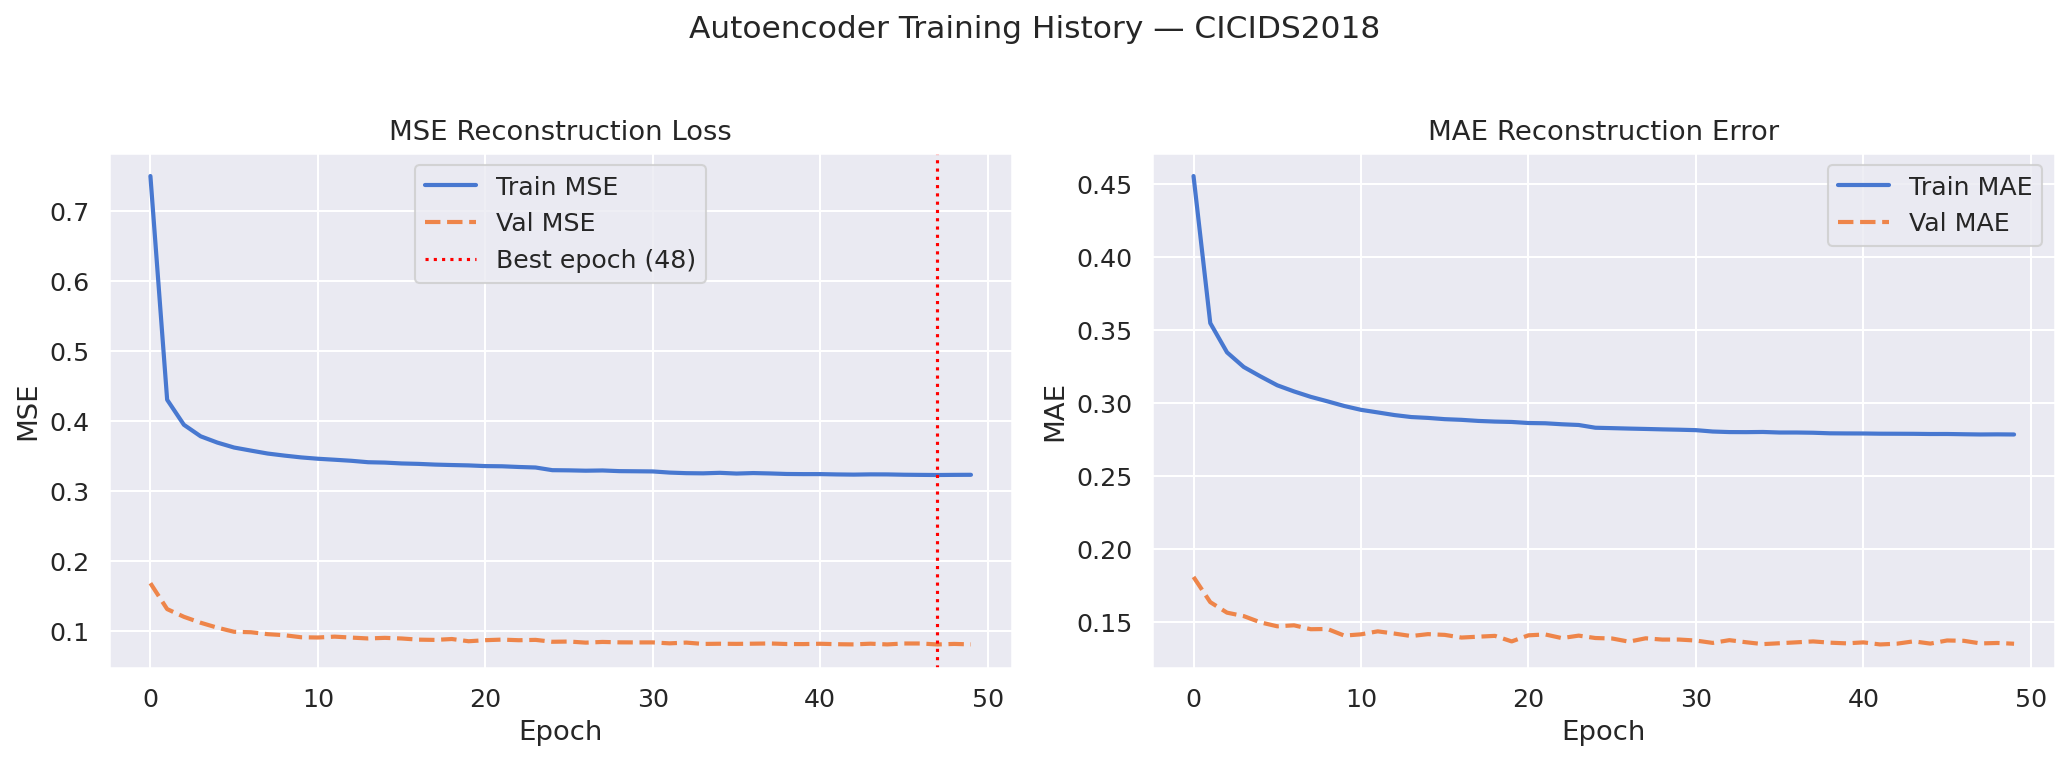

Saved: /home/ubuntu/ids2018/outputs/plot_training_history.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_dict["loss"],     label="Train MSE", linewidth=2)
axes[0].plot(history_dict["val_loss"], label="Val MSE",   linewidth=2, linestyle="--")
axes[0].axvline(best_epoch - 1, color="red", linestyle=":", label=f"Best epoch ({best_epoch})")
axes[0].set_title("MSE Reconstruction Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].plot(history_dict["mae"],     label="Train MAE", linewidth=2)
axes[1].plot(history_dict["val_mae"], label="Val MAE",   linewidth=2, linestyle="--")
axes[1].set_title("MAE Reconstruction Error")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()

plt.suptitle("Autoencoder Training History — CICIDS2018", fontsize=15, y=1.02)
plt.tight_layout()

save_and_show(fig, "plot_training_history.png")

## Cell 15 — Stage 5: Reconstruction Errors  *(cached → `recon_errors.npy` + `val_errors.npy`)*

**First run:** runs inference over the full dataset and saves per-sample MSE arrays.
**Subsequent runs:** loads arrays instantly — no re-inference needed.

In [15]:
# ════════════════════════════════════════════════════════════════════
#  CACHE CHECK — Stage 5
# ════════════════════════════════════════════════════════════════════
if cache_exists(CACHE_RECON_ERRORS, CACHE_VAL_ERRORS):
    print("CACHE HIT — loading reconstruction errors...")
    t0 = time.time()
    recon_errors = np.load(CACHE_RECON_ERRORS)
    val_errors   = np.load(CACHE_VAL_ERRORS)
    print(f"  Loaded {len(recon_errors):,} errors in {time.time()-t0:.1f}s")

else:
    print("CACHE MISS — computing reconstruction errors...")
    t0 = time.time()

    X_recon_all  = autoencoder.predict(X_all_scaled,  batch_size=4096, verbose=1)
    recon_errors = np.mean(np.square(X_all_scaled - X_recon_all), axis=1)
    del X_recon_all; gc.collect()

    # Validation set (benign-only held-out) — used for threshold calibration
    # Using this instead of the test set prevents threshold data leakage
    X_recon_val = autoencoder.predict(X_val_scaled, batch_size=4096, verbose=0)
    val_errors  = np.mean(np.square(X_val_scaled - X_recon_val), axis=1)
    del X_recon_val; gc.collect()

    np.save(CACHE_RECON_ERRORS, recon_errors)
    np.save(CACHE_VAL_ERRORS,   val_errors)
    print(f"  Computed and saved in {time.time()-t0:.1f}s")

print(f"\nBenign mean error : {recon_errors[y_all == 0].mean():.6f}")
print(f"Attack mean error : {recon_errors[y_all == 1].mean():.6f}")
print("\nStage 5 complete")

CACHE HIT — loading reconstruction errors...
  Loaded 3,215,110 errors in 0.1s

Benign mean error : 0.080879
Attack mean error : 0.346754

Stage 5 complete


## Cell 16 — Set Anomaly Threshold

In [16]:
# Threshold calibrated on benign-only VALIDATION errors — no attack leakage.
# P99 = at most ~1% of benign traffic wrongly flagged (FPR ~ 1%).
THRESHOLD = float(np.percentile(val_errors, THRESHOLD_PERCENTILE))

print("Benign validation error percentiles:")
for pct in [50, 90, 95, 99, 99.5, 100]:
    marker = "  <-- THRESHOLD" if pct == THRESHOLD_PERCENTILE else ""
    print(f"  P{pct:<5} : {np.percentile(val_errors, pct):.6f}{marker}")

print(f"\nAnomaly threshold (P{THRESHOLD_PERCENTILE}): {THRESHOLD:.6f}")

thresh_path = os.path.join(OUTPUT_DIR, "threshold.npy")
np.save(thresh_path, THRESHOLD)
print(f"Saved: {thresh_path}")

Benign validation error percentiles:
  P50    : 0.023741
  P90    : 0.159586
  P95    : 0.324563
  P99    : 0.970072  <-- THRESHOLD
  P99.5  : 1.393163
  P100   : 19.975811

Anomaly threshold (P99): 0.970072
Saved: /home/ubuntu/ids2018/outputs/threshold.npy


## Cell 17 — Plot: Reconstruction Error Histogram

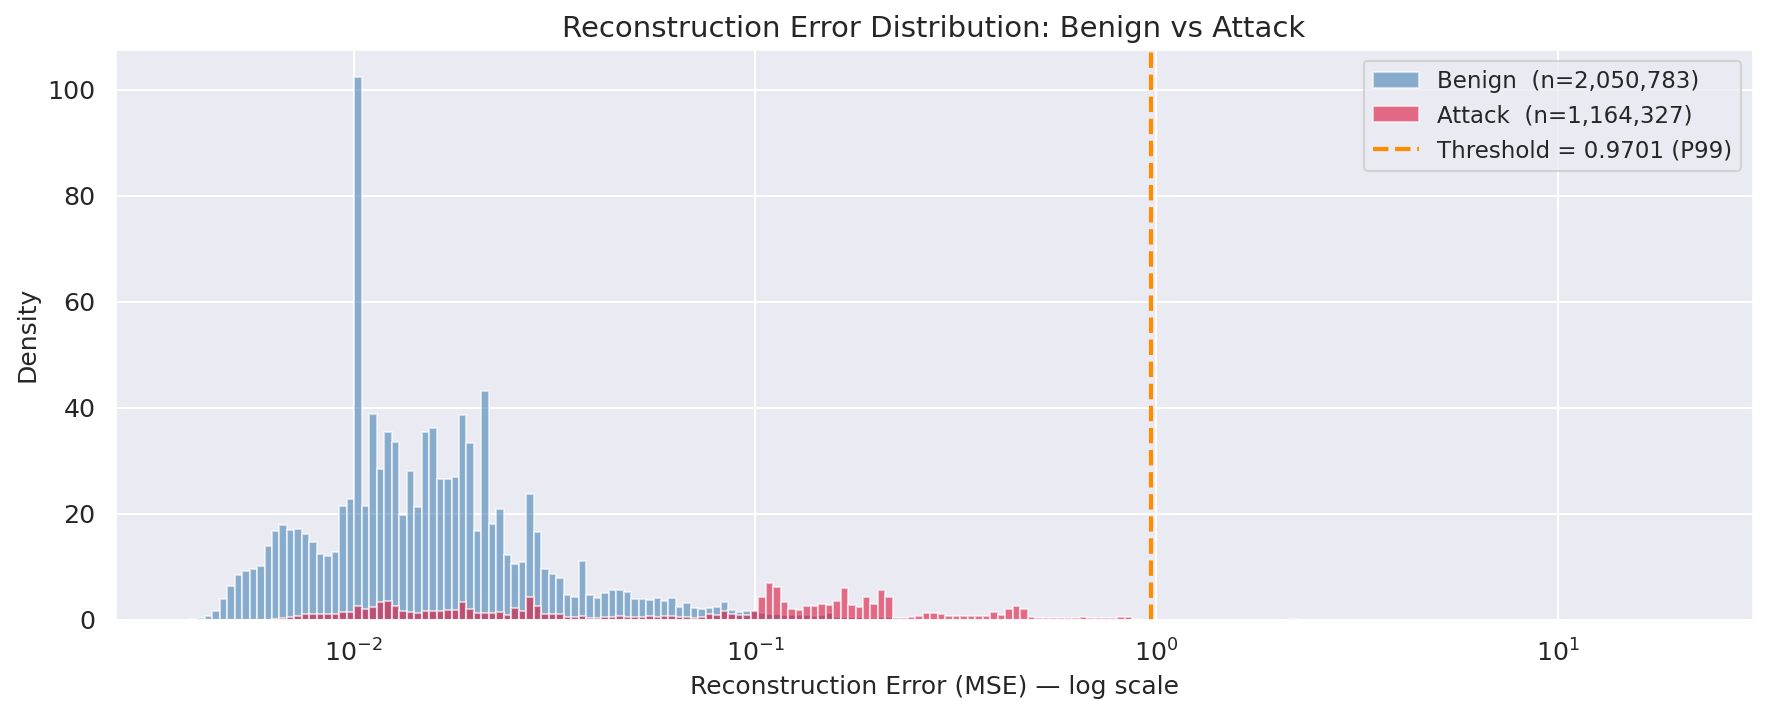

Saved: /home/ubuntu/ids2018/outputs/plot_error_histogram.png


In [17]:
benign_errors = recon_errors[y_all == 0]
attack_errors = recon_errors[y_all == 1]

fig, ax = plt.subplots(figsize=(12, 5))

log_min = np.log10(max(recon_errors.min(), 1e-8))
log_max = np.log10(recon_errors.max() + 1e-8)
bins = np.logspace(log_min, log_max, 200)

ax.hist(benign_errors, bins=bins, alpha=0.6, color="steelblue",
        label=f"Benign  (n={len(benign_errors):,})", density=True)
ax.hist(attack_errors, bins=bins, alpha=0.6, color="crimson",
        label=f"Attack  (n={len(attack_errors):,})", density=True)
ax.axvline(THRESHOLD, color="darkorange", linewidth=2, linestyle="--",
           label=f"Threshold = {THRESHOLD:.4f} (P{THRESHOLD_PERCENTILE})")

ax.set_xscale("log")
ax.set_xlabel("Reconstruction Error (MSE) — log scale", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Reconstruction Error Distribution: Benign vs Attack", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()

save_and_show(fig, "plot_error_histogram.png")

## Cell 18 — Binary Classification Metrics

In [18]:
y_pred = (recon_errors > THRESHOLD).astype(int)  # 1 = flagged as anomaly

tn, fp, fn, tp = confusion_matrix(y_all, y_pred).ravel()
precision = tp / (tp + fp + 1e-10)
recall    = tp / (tp + fn + 1e-10)
op_fpr    = fp / (fp + tn + 1e-10)
f1        = 2 * precision * recall / (precision + recall + 1e-10)
accuracy  = (tp + tn) / len(y_all)

print("=" * 54)
print("   Binary Classification Results")
print("=" * 54)
print(f"  TP (attacks correctly flagged) : {tp:>10,}")
print(f"  TN (benign correctly passed)   : {tn:>10,}")
print(f"  FP (benign wrongly flagged)    : {fp:>10,}")
print(f"  FN (attacks missed)            : {fn:>10,}")
print("-" * 54)
print(f"  Accuracy            : {accuracy:.4f}")
print(f"  Precision           : {precision:.4f}")
print(f"  Recall (TPR)        : {recall:.4f}")
print(f"  False Positive Rate : {op_fpr:.4f}")
print(f"  F1 Score            : {f1:.4f}")
print("\n" + classification_report(
    y_all, y_pred, target_names=["Benign", "Attack"], digits=4
))

   Binary Classification Results
  TP (attacks correctly flagged) :     20,241
  TN (benign correctly passed)   :  2,030,639
  FP (benign wrongly flagged)    :     20,144
  FN (attacks missed)            :  1,144,086
------------------------------------------------------
  Accuracy            : 0.6379
  Precision           : 0.5012
  Recall (TPR)        : 0.0174
  False Positive Rate : 0.0098
  F1 Score            : 0.0336

              precision    recall  f1-score   support

      Benign     0.6396    0.9902    0.7772   2050783
      Attack     0.5012    0.0174    0.0336   1164327

    accuracy                         0.6379   3215110
   macro avg     0.5704    0.5038    0.4054   3215110
weighted avg     0.5895    0.6379    0.5079   3215110



## Cell 19 — Plot: Confusion Matrix

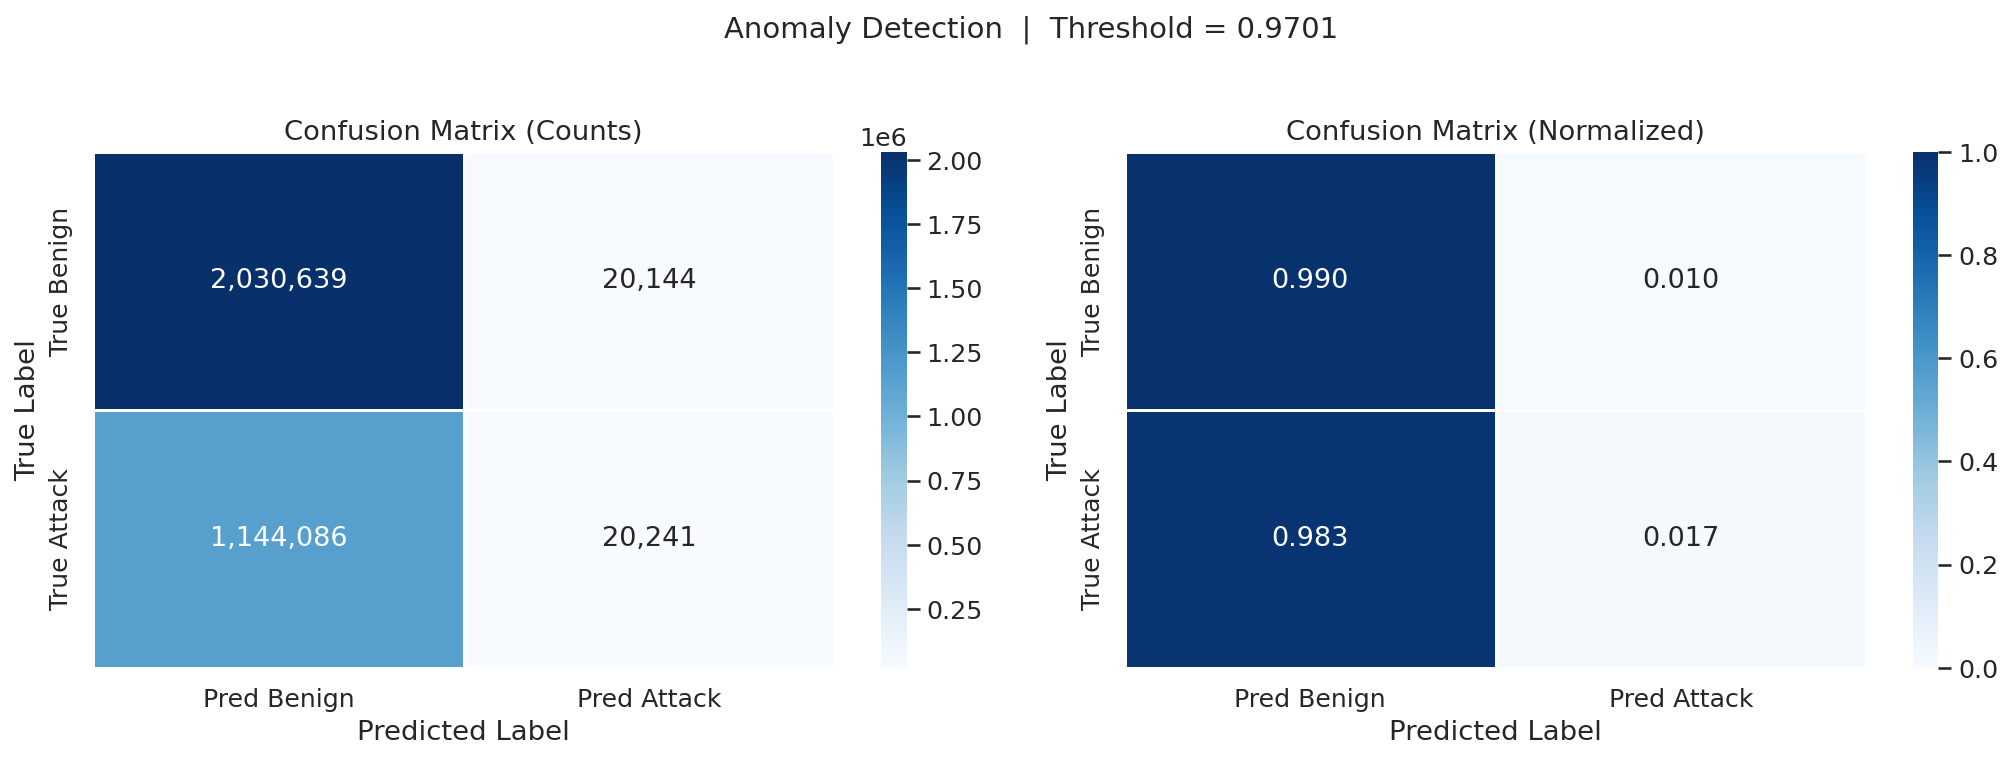

Saved: /home/ubuntu/ids2018/outputs/plot_confusion_matrix.png


In [19]:
cm = confusion_matrix(y_all, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
            xticklabels=["Pred Benign", "Pred Attack"],
            yticklabels=["True Benign", "True Attack"],
            ax=axes[0], linewidths=0.5, annot_kws={"size": 13})
axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="Blues",
            xticklabels=["Pred Benign", "Pred Attack"],
            yticklabels=["True Benign", "True Attack"],
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1, annot_kws={"size": 13})
axes[1].set_title("Confusion Matrix (Normalized)")
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")

plt.suptitle(f"Anomaly Detection  |  Threshold = {THRESHOLD:.4f}", fontsize=14, y=1.02)
plt.tight_layout()

save_and_show(fig, "plot_confusion_matrix.png")

## Cell 20 — ROC Curve

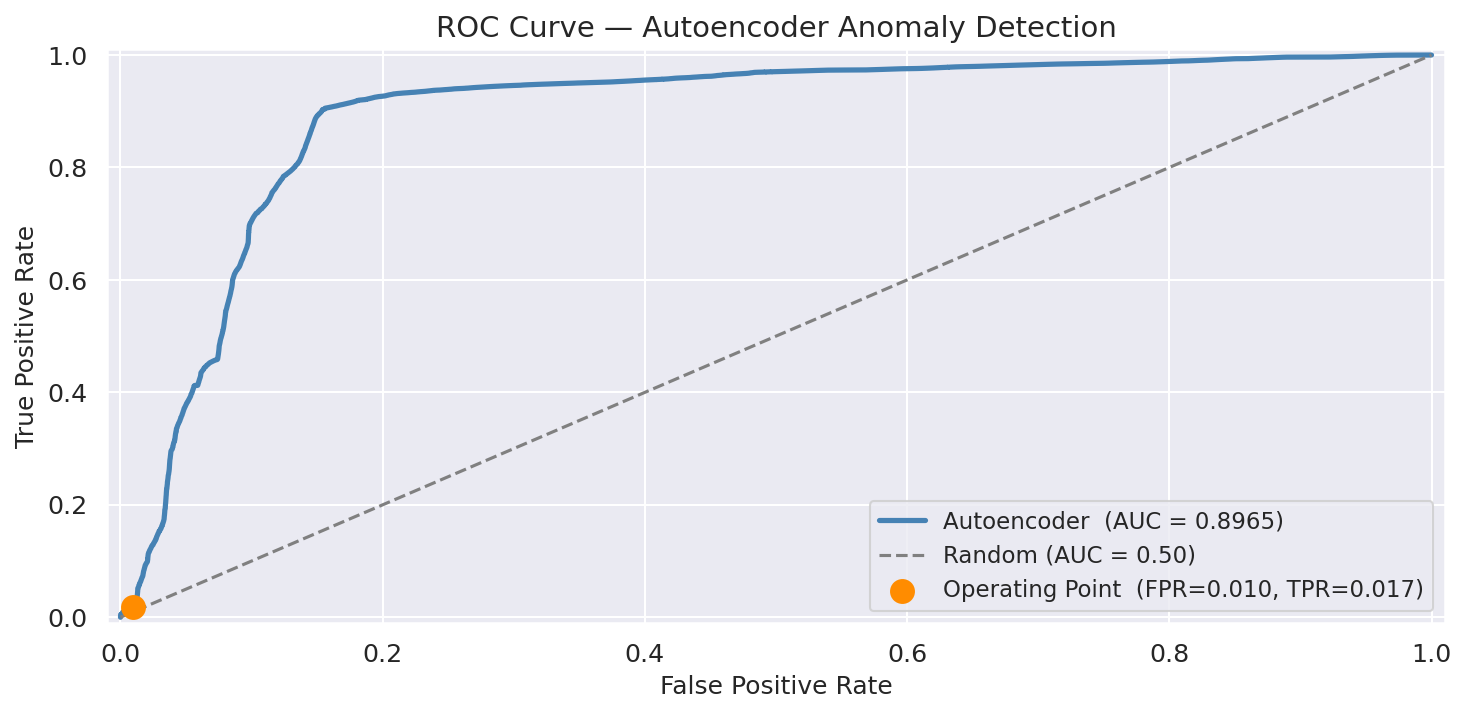

Saved: /home/ubuntu/ids2018/outputs/plot_roc_curve.png
ROC-AUC: 0.8965


In [20]:
fpr_curve, tpr_curve, _ = roc_curve(y_all, recon_errors)
auc_roc = roc_auc_score(y_all, recon_errors)

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(fpr_curve, tpr_curve, color="steelblue", linewidth=2.5,
        label=f"Autoencoder  (AUC = {auc_roc:.4f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--",
        linewidth=1.5, label="Random (AUC = 0.50)")
ax.scatter([op_fpr], [recall], color="darkorange", zorder=5, s=120,
           label=f"Operating Point  (FPR={op_fpr:.3f}, TPR={recall:.3f})")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — Autoencoder Anomaly Detection", fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()

save_and_show(fig, "plot_roc_curve.png")
print(f"ROC-AUC: {auc_roc:.4f}")

## Cell 21 — Precision-Recall Curve

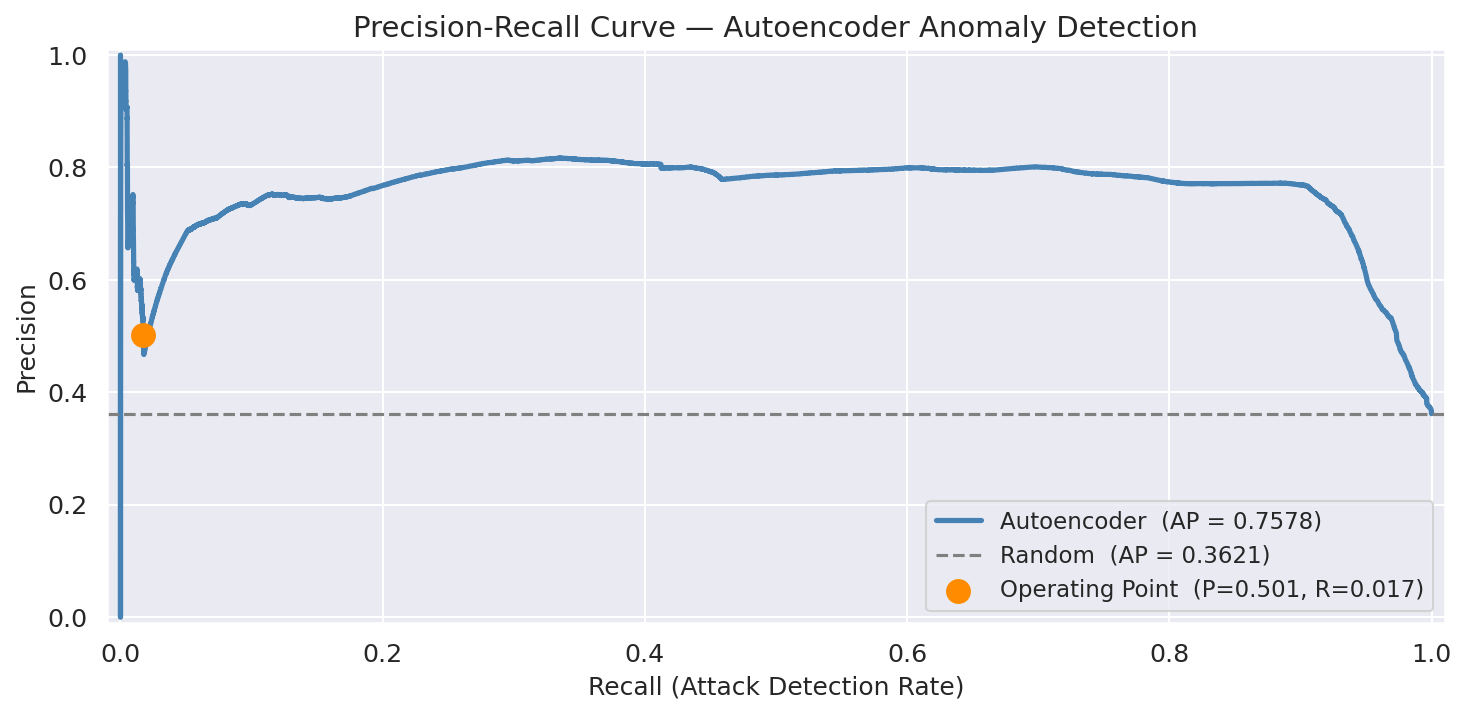

Saved: /home/ubuntu/ids2018/outputs/plot_pr_curve.png
Avg Precision: 0.7578


In [21]:
prec_curve, rec_curve, _ = precision_recall_curve(y_all, recon_errors)
avg_prec    = average_precision_score(y_all, recon_errors)
baseline_pr = y_all.mean()

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(rec_curve, prec_curve, color="steelblue", linewidth=2.5,
        label=f"Autoencoder  (AP = {avg_prec:.4f})")
ax.axhline(baseline_pr, color="gray", linestyle="--", linewidth=1.5,
           label=f"Random  (AP = {baseline_pr:.4f})")
ax.scatter([recall], [precision], color="darkorange", zorder=5, s=120,
           label=f"Operating Point  (P={precision:.3f}, R={recall:.3f})")

ax.set_xlabel("Recall (Attack Detection Rate)", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve — Autoencoder Anomaly Detection", fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()

save_and_show(fig, "plot_pr_curve.png")
print(f"Avg Precision: {avg_prec:.4f}")

## Cell 22 — Per-Attack-Type Detection Rate

In [22]:
attack_mask     = y_all == 1
attack_types    = labels_all[attack_mask]
attack_errors_t = recon_errors[attack_mask]
attack_preds    = y_pred[attack_mask]
unique_attacks  = sorted(set(attack_types))

rows = []
for atype in unique_attacks:
    mask       = attack_types == atype
    n_total    = mask.sum()
    n_detected = attack_preds[mask].sum()
    rows.append({
        "Attack Type"        : atype,
        "Total Samples"      : n_total,
        "Detected"           : n_detected,
        "Detection Rate (%)" : round(100 * n_detected / n_total, 2),
        "Mean Recon Error"   : round(float(attack_errors_t[mask].mean()), 6)
    })

df_results = pd.DataFrame(rows).sort_values("Detection Rate (%)", ascending=False)
print(df_results.to_string(index=False))

results_csv = os.path.join(OUTPUT_DIR, "per_attack_results.csv")
df_results.to_csv(results_csv, index=False)
print(f"\nSaved: {results_csv}")

             Attack Type  Total Samples  Detected  Detection Rate (%)  Mean Recon Error
    DDOS attack-LOIC-UDP           1730      1730              100.00          8.941455
   DoS attacks-Slowloris           9908      7295               73.63          2.712633
        Brute Force -XSS            228       109               47.81          1.225579
        Brute Force -Web            553       132               23.87          0.403840
   DoS attacks-GoldenEye          41406      8413               20.32          0.671758
           SQL Injection             84         6                7.14          0.279572
          FTP-BruteForce             55         2                3.64          0.298500
           Infilteration          90390      1057                1.17          0.110109
                     Bot         144535       653                0.45          0.126820
  DDoS attacks-LOIC-HTTP         498301       751                0.15          0.326453
        DoS attacks-Hulk        

## Cell 23 — Plot: Per-Attack Detection Rate Bar Chart

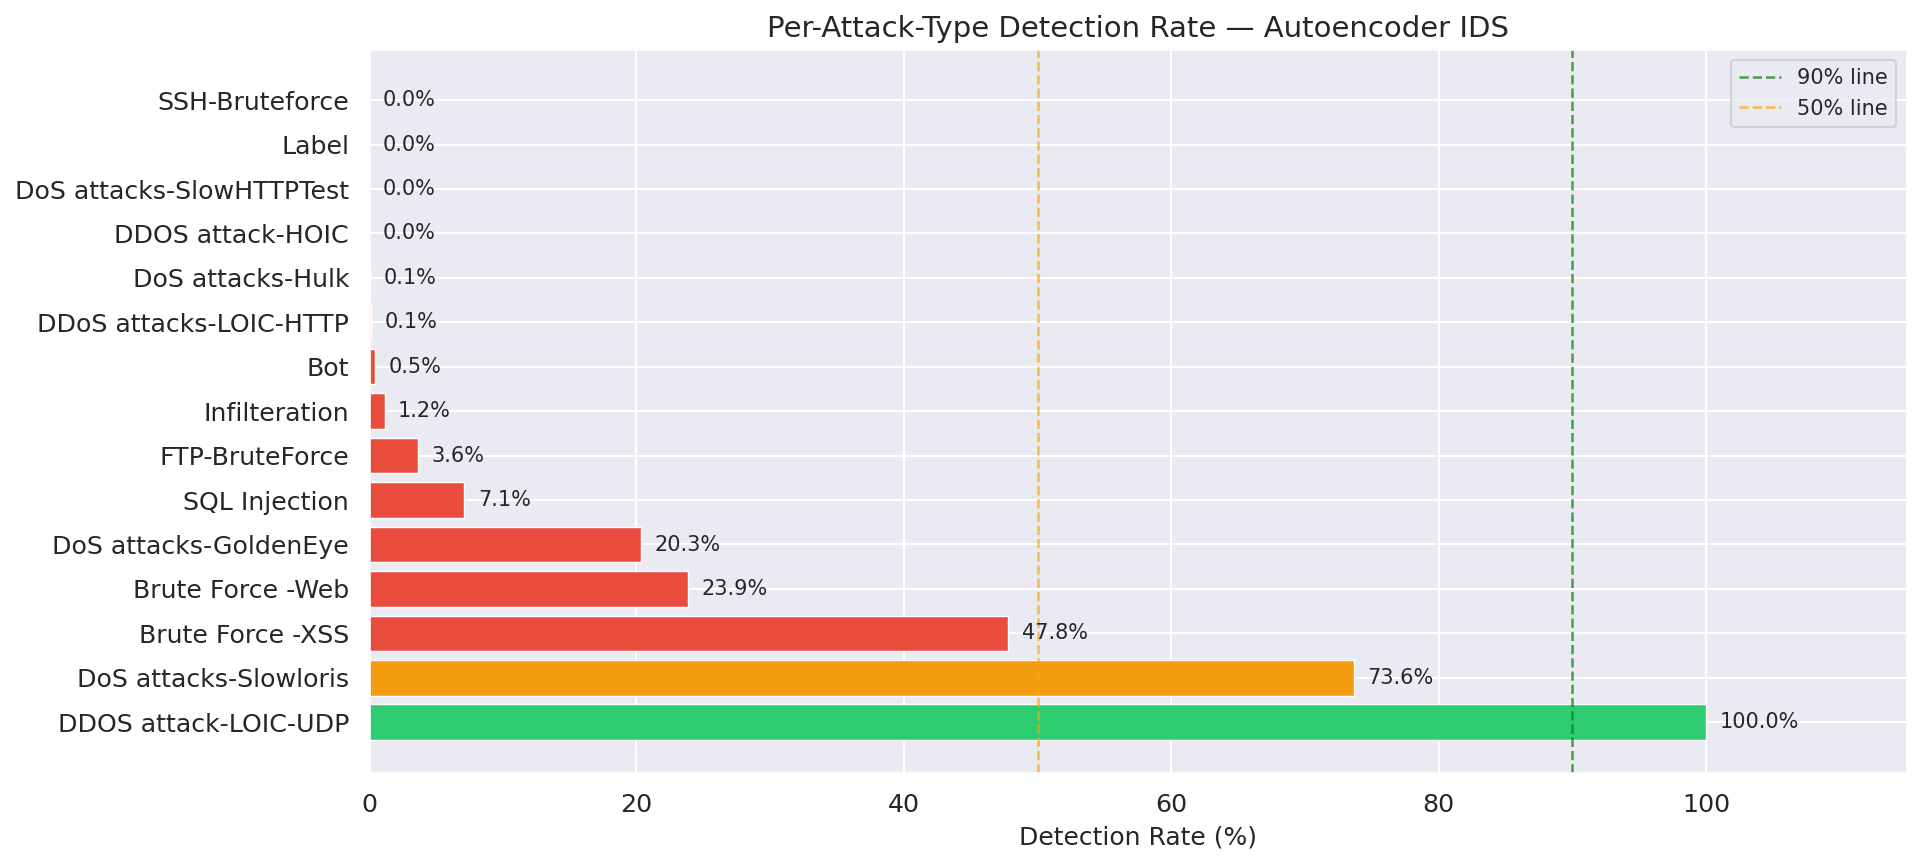

Saved: /home/ubuntu/ids2018/outputs/plot_per_attack_detection.png


In [23]:
fig, ax = plt.subplots(figsize=(13, 6))

colors = ["#2ECC71" if r >= 90 else "#F39C12" if r >= 60 else "#E74C3C"
          for r in df_results["Detection Rate (%)"]]

bars = ax.barh(df_results["Attack Type"], df_results["Detection Rate (%)"],
               color=colors, edgecolor="white", linewidth=0.7)

for bar, val in zip(bars, df_results["Detection Rate (%)"]):
    ax.text(min(val + 1, 102), bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", ha="left", fontsize=10)

ax.axvline(90, color="green",  linestyle="--", linewidth=1.2, alpha=0.7, label="90% line")
ax.axvline(50, color="orange", linestyle="--", linewidth=1.2, alpha=0.7, label="50% line")
ax.set_xlabel("Detection Rate (%)", fontsize=12)
ax.set_title("Per-Attack-Type Detection Rate — Autoencoder IDS", fontsize=14)
ax.set_xlim(0, 115)
ax.legend(fontsize=10)
plt.tight_layout()

save_and_show(fig, "plot_per_attack_detection.png")

## Cell 24 — Threshold Sensitivity Analysis

Threshold Sensitivity:

 Percentile  Threshold  TPR (Recall) %  FPR %     F1     TP     FP      FN
       90.0   0.159586           70.46   9.99 0.7494 820363 204831  343964
       95.0   0.324563           37.82   5.00 0.5159 440383 102621  723944
       97.0   0.509043           15.44   3.00 0.2558 179772  61439  984555
       98.0   0.661412            9.70   2.00 0.1713 112942  41045 1051385
       99.0   0.970072            1.74   0.98 0.0336  20241  20144 1144086
       99.5   1.393163            1.28   0.49 0.0252  14960  10130 1149367


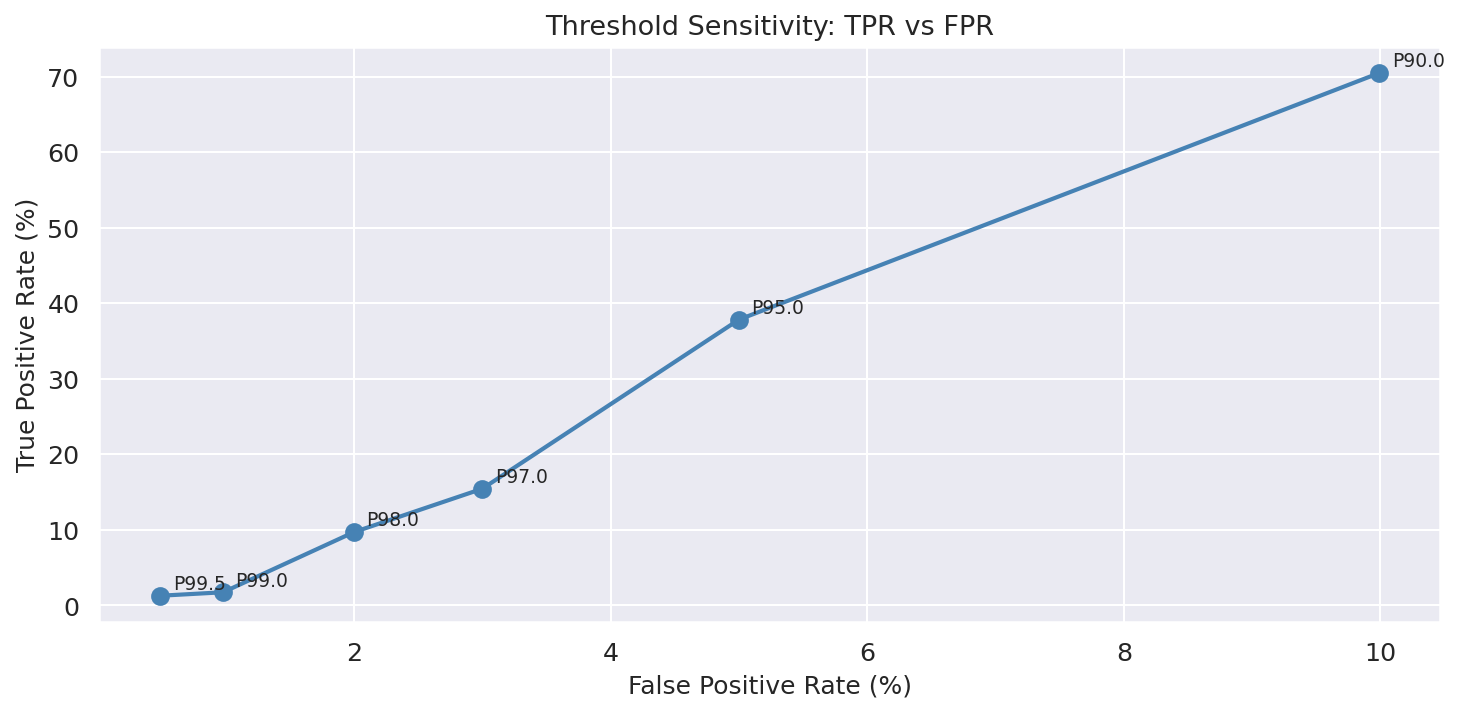

Saved: /home/ubuntu/ids2018/outputs/plot_threshold_sensitivity.png


In [24]:
percentiles = [90, 95, 97, 98, 99, 99.5]
rows = []
for p in percentiles:
    thresh = np.percentile(val_errors, p)
    preds  = (recon_errors > thresh).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_all, preds).ravel()
    rows.append({
        "Percentile"     : p,
        "Threshold"      : round(thresh, 6),
        "TPR (Recall) %" : round(100 * tp_ / (tp_ + fn_ + 1e-9), 2),
        "FPR %"          : round(100 * fp_ / (fp_ + tn_ + 1e-9), 2),
        "F1"             : round(f1_score(y_all, preds), 4),
        "TP"             : tp_,
        "FP"             : fp_,
        "FN"             : fn_,
    })

df_thresh = pd.DataFrame(rows)
print("Threshold Sensitivity:\n")
print(df_thresh.to_string(index=False))

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(df_thresh["FPR %"], df_thresh["TPR (Recall) %"],
        marker="o", linewidth=2, markersize=8, color="steelblue")
for _, row in df_thresh.iterrows():
    ax.annotate(f"P{row['Percentile']}",
                (row["FPR %"], row["TPR (Recall) %"]),
                textcoords="offset points", xytext=(6, 3), fontsize=9)
ax.set_xlabel("False Positive Rate (%)", fontsize=12)
ax.set_ylabel("True Positive Rate (%)", fontsize=12)
ax.set_title("Threshold Sensitivity: TPR vs FPR", fontsize=13)
plt.tight_layout()

save_and_show(fig, "plot_threshold_sensitivity.png")

## Cell 25 — Save Final Model & Artefacts

In [25]:
final_model_path = os.path.join(OUTPUT_DIR, "autoencoder_final.keras")
autoencoder.save(final_model_path)
print(f"Model  : {final_model_path}")

final_scaler_path = os.path.join(OUTPUT_DIR, "robust_scaler.joblib")
joblib.dump(scaler, final_scaler_path)
print(f"Scaler : {final_scaler_path}")

print("\n" + "=" * 58)
print("  All saved files")
print("=" * 58)
for directory, label in [(OUTPUT_DIR, "OUTPUTS"), (CACHE_DIR, "CACHE")]:
    print(f"\n  [{label}]  {directory}")
    for fname in sorted(os.listdir(directory)):
        fpath = os.path.join(directory, fname)
        if os.path.isfile(fpath):
            size_mb = os.path.getsize(fpath) / (1024**2)
            print(f"    {fname:<46}  {size_mb:>6.1f} MB")

Model  : /home/ubuntu/ids2018/outputs/autoencoder_final.keras
Scaler : /home/ubuntu/ids2018/outputs/robust_scaler.joblib

  All saved files

  [OUTPUTS]  /home/ubuntu/ids2018/outputs
    autoencoder_best.keras                             0.5 MB
    autoencoder_final.keras                            0.5 MB
    per_attack_results.csv                             0.0 MB
    plot_confusion_matrix.png                          0.1 MB
    plot_error_histogram.png                           0.1 MB
    plot_per_attack_detection.png                      0.1 MB
    plot_pr_curve.png                                  0.1 MB
    plot_roc_curve.png                                 0.1 MB
    plot_threshold_sensitivity.png                     0.1 MB
    plot_training_history.png                          0.1 MB
    robust_scaler.joblib                               0.0 MB
    threshold.npy                                      0.0 MB

  [CACHE]  /home/ubuntu/ids2018/cache
    X_all_scaled.npy              

## Cell 26 — Final Summary & Zero-Day Analysis

In [26]:
print("=" * 65)
print("      FINAL SUMMARY — CICIDS2018 Autoencoder IDS")
print("=" * 65)
print(f"""
1. DATASET
   Total samples    : {len(df):,}
   Feature dims     : {INPUT_DIM}
   Benign traffic   : {n_benign:,}  ({100*n_benign/len(df):.1f}%)
   Attack traffic   : {n_attack:,}  ({100*n_attack/len(df):.1f}%)
   Attack types     : {len(unique_attacks)}

2. MODEL
   Architecture     : {INPUT_DIM}->128->64->{ENCODING_DIM}->64->128->{INPUT_DIM}
   Parameters       : {autoencoder.count_params():,}
   Best val MSE     : {best_loss:.6f}
   Best epoch       : {best_epoch}
   Threshold (P{THRESHOLD_PERCENTILE})   : {THRESHOLD:.6f}

3. DETECTION PERFORMANCE
   ROC-AUC          : {auc_roc:.4f}
   Avg Precision    : {avg_prec:.4f}
   F1 Score         : {f1:.4f}
   Recall (TPR)     : {recall:.4f}  -> detects {100*recall:.1f}% of attacks
   False Pos Rate   : {op_fpr:.4f}  -> {100*op_fpr:.1f}% of benign wrongly flagged
   Missed attacks   : {fn:,}

4. ZERO-DAY READINESS
   Trained ONLY on benign traffic — never saw any attacks.
   Detects attacks by measuring deviation from learned normal.
   High AUC (>0.9) = strong benign/attack error separation.
   Threshold adjustable without retraining the model.

5. CACHING SUMMARY
   ~/ids2018/cache/   — all intermediate results (parquet, npy, joblib)
   ~/ids2018/outputs/ — final model, scaler, threshold, plots, results CSV

   To re-run a specific stage: delete its cache file(s) and re-run those cells.
   To re-run everything:       set FORCE_RERUN = True in Cell 2.

   Cache file -> stage mapping:
     cleaned_data.parquet       Stage 1+2  (CSV loading + cleaning)
     X_*_scaled.npy, scaler     Stage 3    (splitting + scaling)
     autoencoder_best.keras     Stage 4    (model training)
     train_history.npy          Stage 4    (training history / plots)
     recon_errors.npy           Stage 5    (reconstruction errors)
     val_errors.npy             Stage 5    (threshold calibration errors)
""")
print("=" * 65)

      FINAL SUMMARY — CICIDS2018 Autoencoder IDS

1. DATASET
   Total samples    : 3,215,110
   Feature dims     : 68
   Benign traffic   : 2,050,783  (63.8%)
   Attack traffic   : 1,164,327  (36.2%)
   Attack types     : 15

2. MODEL
   Architecture     : 68->128->64->32->64->128->68
   Parameters       : 39,908
   Best val MSE     : 0.081053
   Best epoch       : 48
   Threshold (P99)   : 0.970072

3. DETECTION PERFORMANCE
   ROC-AUC          : 0.8965
   Avg Precision    : 0.7578
   F1 Score         : 0.0336
   Recall (TPR)     : 0.0174  -> detects 1.7% of attacks
   False Pos Rate   : 0.0098  -> 1.0% of benign wrongly flagged
   Missed attacks   : 1,144,086

4. ZERO-DAY READINESS
   Trained ONLY on benign traffic — never saw any attacks.
   Detects attacks by measuring deviation from learned normal.
   High AUC (>0.9) = strong benign/attack error separation.
   Threshold adjustable without retraining the model.

5. CACHING SUMMARY
   ~/ids2018/cache/   — all intermediate results (pa